# Canonical Protocol: Multi-Embedding Comparison

Runs canonical (C) on SumMe & TVSum for: GoogLeNet 1024, CLIP 1024, DINOv2 1024, CLIP 768.
Each embedding trained/tested separately on each dataset with 5-fold splits.

## 1) Config & Paths

In [9]:
from pathlib import Path
import os
import sys

# === UPDATE THESE PATHS ===
REPO_SRC = "/kaggle/input/datasets/ayabenmansour12/video-sum-code/pytorch-vsumm-reinforce"

# Embedding: {embedding_name: {summe_h5, tvsum_h5, input_dim}}
EMBEDDINGS = {
    'googlenet_1024': {
        'summe_h5': '/kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5',
        'tvsum_h5': '/kaggle/input/datasets/ayabenmansour12/video-sum-tvsum/eccv16_dataset_tvsum_google_pool5.h5',
        'input_dim': 1024,
    },
    'clip_1024': {
        'summe_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_clip_rn50x64.h5',
        'tvsum_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_rn50x64.h5',
        'input_dim': 1024,
    },
    'dinov2_1024': {
        'summe_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_dinov2_vitl14.h5',
        'tvsum_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_dinov2_vitl14.h5',
        'input_dim': 1024,
    },
    'clip_768': {
        'summe_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_summe_clip_vitl14.h5',
        'tvsum_h5': '/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5',
        'input_dim': 768,
    },
}

SEED = 1
MAX_EPOCHS = 60  # Increase to 80-120 if desired (you have 90GB GPU)
GPU_ID = '0'
NUM_SPLITS = 5

WORK_DIR = '/kaggle/working/vsum_canonical'
SPLITS_DIR = '/kaggle/working/splits_canonical'
OUT_BASE = '/kaggle/working/canonical_results'

Path(WORK_DIR).mkdir(parents=True, exist_ok=True)
Path(SPLITS_DIR).mkdir(parents=True, exist_ok=True)
Path(OUT_BASE).mkdir(parents=True, exist_ok=True)
print('Paths configured.')

Paths configured.


## 2) Setup & Dependencies

In [10]:
import shutil
import numpy as np

!pip -q install tabulate h5py

if not (Path(WORK_DIR) / 'main.py').exists():
    shutil.copytree(REPO_SRC, WORK_DIR, dirs_exist_ok=True)

sys.path.insert(0, WORK_DIR)
print('Code ready at:', WORK_DIR)

Code ready at: /kaggle/working/vsum_canonical


## 3) Reproducibility

In [11]:
import torch
import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('GPU not available')
print('Torch:', torch.__version__)

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Torch: 2.10.0+cu128


## 4) H5 Sanity Check

In [12]:
import h5py

def check_h5(path):
    with h5py.File(path, 'r') as f:
        keys = list(f.keys())
        print('  Videos:', len(keys))
        if keys:
            k = keys[0]
            grp = f[k]
            print('  Features shape:', grp['features'].shape)

for emb, cfg in EMBEDDINGS.items():
    print(f'{emb}:')
    print('  SumMe:')
    check_h5(cfg['summe_h5'])
    print('  TVSum:')
    check_h5(cfg['tvsum_h5'])

googlenet_1024:
  SumMe:
  Videos: 25
  Features shape: (300, 1024)
  TVSum:
  Videos: 50
  Features shape: (707, 1024)
clip_1024:
  SumMe:
  Videos: 25
  Features shape: (300, 1024)
  TVSum:
  Videos: 50
  Features shape: (707, 1024)
dinov2_1024:
  SumMe:
  Videos: 25
  Features shape: (300, 1024)
  TVSum:
  Videos: 50
  Features shape: (707, 1024)
clip_768:
  SumMe:
  Videos: 25
  Features shape: (300, 768)
  TVSum:
  Videos: 50
  Features shape: (707, 768)


## 5) Run Canonical Experiments

In [13]:
import subprocess
import shlex

def run_cmd(cmd):
    print('\n$', cmd)
    subprocess.run(shlex.split(cmd), check=True)

def make_splits(h5_path, save_name):
    split_path = Path(SPLITS_DIR) / f'{save_name}_splits.json'
    if not split_path.exists():
        cmd = f'python {WORK_DIR}/create_split.py -d {h5_path} --save-dir {SPLITS_DIR} --save-name {save_name}_splits --num-splits {NUM_SPLITS}'
        run_cmd(cmd)
    return str(split_path)

# Main loop: for each embedding, train SumMe and TVSum with 5 splits each
for emb_name, cfg in EMBEDDINGS.items():
    print(f'\n\n===== {emb_name} =====')
    
    input_dim = cfg['input_dim']
    
    for dataset_type, metric in [('summe', 'summe'), ('tvsum', 'tvsum')]:
        h5_path = cfg[f'{dataset_type}_h5']
        split_path = make_splits(h5_path, f'{emb_name}_{dataset_type}')
        
        for split_id in range(NUM_SPLITS):
            out_dir = Path(OUT_BASE) / emb_name / f'{dataset_type}_split{split_id}'
            out_dir.mkdir(parents=True, exist_ok=True)
            
            print(f'\n--- {emb_name} {dataset_type.upper()} split {split_id} ---')
            
            # Train (with input-dim for variable embedding dimensions)
            cmd = f'python {WORK_DIR}/main.py -d {h5_path} -s {split_path} -m {metric} --gpu {GPU_ID} --save-dir {out_dir} --split-id {split_id} --input-dim {input_dim} --verbose --max-epoch {MAX_EPOCHS}'
            run_cmd(cmd)
            
            # Evaluate
            ckpt = out_dir / f'model_epoch{MAX_EPOCHS}.pth.tar'
            if ckpt.exists():
                cmd = f'python {WORK_DIR}/main.py -d {h5_path} -s {split_path} -m {metric} --gpu {GPU_ID} --save-dir {out_dir} --split-id {split_id} --input-dim {input_dim} --evaluate --resume {ckpt} --verbose --save-results'
                run_cmd(cmd)
            else:
                print('WARNING: Checkpoint not found:', ckpt)



===== googlenet_1024 =====

--- googlenet_1024 SUMME split 0 ---

$ python /kaggle/working/vsum_canonical/main.py -d /kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5 -s /kaggle/working/splits_canonical/googlenet_1024_summe_splits.json -m summe --gpu 0 --save-dir /kaggle/working/canonical_results/googlenet_1024/summe_split0 --split-id 0 --input-dim 1024 --verbose --max-epoch 60


/kaggle/working/vsum_canonical/rewards.py:47: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, _seq, _seq.t())


Args:Namespace(dataset='/kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5', split='/kaggle/working/splits_canonical/googlenet_1024_summe_splits.json', split_id=0, metric='summe', input_dim=1024, hidden_dim=256, num_layers=1, rnn_cell='lstm', lr=1e-05, weight_decay=1e-05, max_epoch=60, stepsize=30, gamma=0.1, num_episode=5, beta=0.01, seed=1, gpu='0', use_cpu=False, evaluate=False, save_dir='/kaggle/working/canonical_results/googlenet_1024/summe_split0', resume='', verbose=True, save_results=False)
Currently using GPU 0
Initialize dataset /kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5
# total videos 25. # train videos 20. # test videos 5
Initialize model
Model size: 2.62605M
==> Start training
epoch 1/60	 reward 0.8938391047716138	
epoch 2/60	 reward 0.8932885414361953	
epoch 3/60	 reward 0.8928476279973984	
epoch 4/60	 reward 0.892452701330185	
epoch 5/60	 reward 0.8939740800857543	
epoch 6/60	 rewar

/kaggle/working/vsum_canonical/rewards.py:47: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, _seq, _seq.t())


Args:Namespace(dataset='/kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5', split='/kaggle/working/splits_canonical/googlenet_1024_summe_splits.json', split_id=1, metric='summe', input_dim=1024, hidden_dim=256, num_layers=1, rnn_cell='lstm', lr=1e-05, weight_decay=1e-05, max_epoch=60, stepsize=30, gamma=0.1, num_episode=5, beta=0.01, seed=1, gpu='0', use_cpu=False, evaluate=False, save_dir='/kaggle/working/canonical_results/googlenet_1024/summe_split1', resume='', verbose=True, save_results=False)
Currently using GPU 0
Initialize dataset /kaggle/input/datasets/ayabenmansour12/video-sum-summe/eccv16_dataset_summe_google_pool5.h5
# total videos 25. # train videos 20. # test videos 5
Initialize model
Model size: 2.62605M
==> Start training
epoch 1/60	 reward 0.8829055857658388	
epoch 2/60	 reward 0.8830422049760818	
epoch 3/60	 reward 0.8835996192693709	
epoch 4/60	 reward 0.8831051087379453	
epoch 5/60	 reward 0.8847295296192168	
epoch 6/60	 rewa

...

Args:Namespace(dataset='/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5', split='/kaggle/working/splits_canonical/clip_768_tvsum_splits.json', split_id=2, metric='tvsum', input_dim=768, hidden_dim=256, num_layers=1, rnn_cell='lstm', lr=1e-05, weight_decay=1e-05, max_epoch=60, stepsize=30, gamma=0.1, num_episode=5, beta=0.01, seed=1, gpu='0', use_cpu=False, evaluate=False, save_dir='/kaggle/working/canonical_results/clip_768/tvsum_split2', resume='', verbose=True, save_results=False)
Currently using GPU 0
Initialize dataset /kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5
# total videos 50. # train videos 40. # test videos 10
Initialize model
Model size: 2.10176M
==> Start training
epoch 1/60	 reward 0.4586378982663154	
epoch 2/60	 reward 0.4587834726274013	
epoch 3/60	 reward 0.4588454900681972	
epoch 4/60	 reward 0.4586269119381905	
epoch 5

/kaggle/working/vsum_canonical/rewards.py:47: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, _seq, _seq.t())


Args:Namespace(dataset='/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5', split='/kaggle/working/splits_canonical/clip_768_tvsum_splits.json', split_id=3, metric='tvsum', input_dim=768, hidden_dim=256, num_layers=1, rnn_cell='lstm', lr=1e-05, weight_decay=1e-05, max_epoch=60, stepsize=30, gamma=0.1, num_episode=5, beta=0.01, seed=1, gpu='0', use_cpu=False, evaluate=False, save_dir='/kaggle/working/canonical_results/clip_768/tvsum_split3', resume='', verbose=True, save_results=False)
Currently using GPU 0
Initialize dataset /kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5
# total videos 50. # train videos 40. # test videos 10
Initialize model
Model size: 2.10176M
==> Start training
epoch 1/60	 reward 0.4579224134981633	
epoch 2/60	 reward 0.45791609317064286	
epoch 3/60	 reward 0.4578786815702915	
epoch 4/60	 reward 0.4577340012788772	
epoch 

/kaggle/working/vsum_canonical/rewards.py:47: UserWarning: This overload of addmm_ is deprecated:
	addmm_(Number beta, Number alpha, Tensor mat1, Tensor mat2)
Consider using one of the following signatures instead:
	addmm_(Tensor mat1, Tensor mat2, *, Number beta = 1, Number alpha = 1) (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:1862.)
  dist_mat.addmm_(1, -2, _seq, _seq.t())


Args:Namespace(dataset='/kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5', split='/kaggle/working/splits_canonical/clip_768_tvsum_splits.json', split_id=4, metric='tvsum', input_dim=768, hidden_dim=256, num_layers=1, rnn_cell='lstm', lr=1e-05, weight_decay=1e-05, max_epoch=60, stepsize=30, gamma=0.1, num_episode=5, beta=0.01, seed=1, gpu='0', use_cpu=False, evaluate=False, save_dir='/kaggle/working/canonical_results/clip_768/tvsum_split4', resume='', verbose=True, save_results=False)
Currently using GPU 0
Initialize dataset /kaggle/input/datasets/mariahadjmessaoud/tvsum-and-summe-embeddings/h5_files/h5_files/eccv16_dataset_tvsum_clip_vitl14.h5
# total videos 50. # train videos 40. # test videos 10
Initialize model
Model size: 2.10176M
==> Start training
epoch 1/60	 reward 0.45794439911842344	
epoch 2/60	 reward 0.458012817800045	
epoch 3/60	 reward 0.4580032390356064	
epoch 4/60	 reward 0.45783737093210225	
epoch 

## 6) Results Summary & Comparison

In [14]:
import re
from tabulate import tabulate

def parse_fscore(log_path):
    if not log_path.exists():
        return None
    text = log_path.read_text(encoding='utf-8', errors='ignore')
    match = re.search(r'Average F-score\s+([0-9.]+)%', text)
    if match:
        return float(match.group(1))
    return None

rows = []
for emb_name in EMBEDDINGS.keys():
    for dataset_type in ('summe', 'tvsum'):
        scores = []
        for split_id in range(NUM_SPLITS):
            log_path = Path(OUT_BASE) / emb_name / f'{dataset_type}_split{split_id}' / 'log_test.txt'
            score = parse_fscore(log_path)
            if score is not None:
                scores.append(score)
        
        mean = float(np.mean(scores)) if scores else None
        std = float(np.std(scores)) if scores else None
        rows.append([emb_name, dataset_type.upper(), f'{mean:.2f}' if mean else '-', f'{std:.2f}' if std else '-', len(scores)])

print('\n\nCanonical Results (F-score % by embedding and dataset)')
print(tabulate(rows, headers=['Embedding', 'Dataset', 'Mean %', 'Std %', 'Splits'], tablefmt='github'))



Canonical Results (F-score % by embedding and dataset)
| Embedding      | Dataset   |   Mean % |   Std % |   Splits |
|----------------|-----------|----------|---------|----------|
| googlenet_1024 | SUMME     |    38.32 |    7.99 |        5 |
| googlenet_1024 | TVSUM     |    56.44 |    1.88 |        5 |
| clip_1024      | SUMME     |    42.54 |    5.09 |        5 |
| clip_1024      | TVSUM     |    57.58 |    2.85 |        5 |
| dinov2_1024    | SUMME     |    42.26 |    4.53 |        5 |
| dinov2_1024    | TVSUM     |    60.56 |    0.82 |        5 |
| clip_768       | SUMME     |    36.76 |    3.75 |        5 |
| clip_768       | TVSUM     |    57.5  |    2.72 |        5 |


## 7) Plots & Visualization

✓ Parsed 60 epochs from googlenet_1024 summe
✓ Parsed 60 epochs from googlenet_1024 tvsum
✓ Parsed 60 epochs from clip_1024 summe
✓ Parsed 60 epochs from clip_1024 tvsum
✓ Parsed 60 epochs from dinov2_1024 summe
✓ Parsed 60 epochs from dinov2_1024 tvsum
✓ Parsed 60 epochs from clip_768 summe
✓ Parsed 60 epochs from clip_768 tvsum


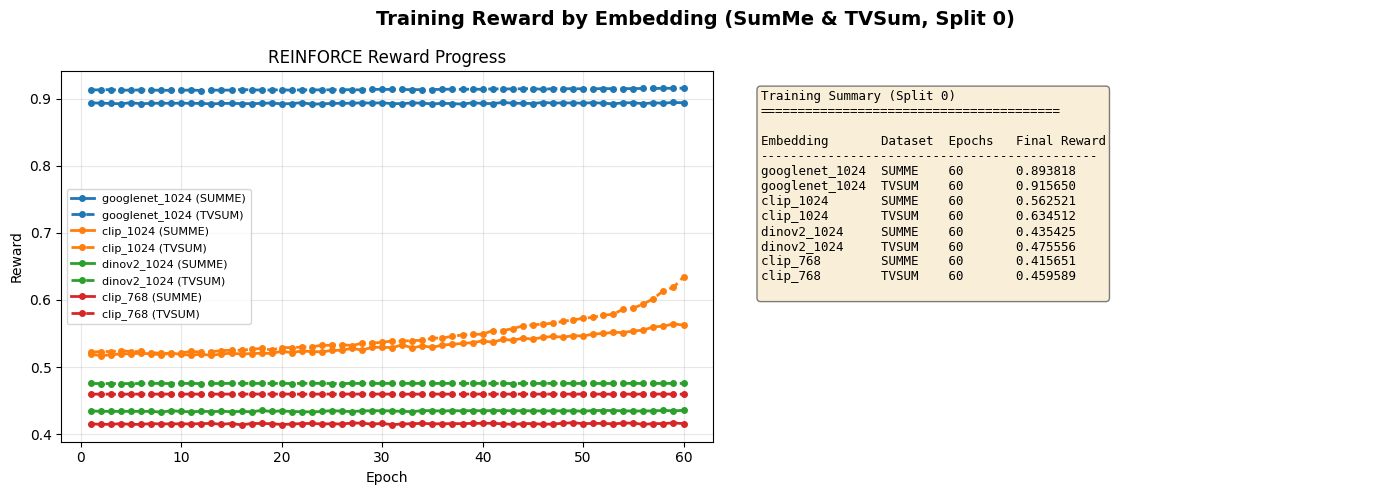


 Training analysis complete!


In [27]:
import matplotlib.pyplot as plt
import re

def parse_train_log(log_path):
    """Extract epoch and reward from training log."""
    if not log_path.exists():
        return [], []
    
    text = log_path.read_text(encoding='utf-8', errors='ignore')
    
    epochs = []
    rewards = []
    
    # Pattern: "epoch 1/60	 reward 0.8938391047716138"
    for line in text.split('\n'):
        if 'epoch' in line and 'reward' in line:
            try:
                # Extract epoch number
                epoch_match = re.search(r'epoch\s+(\d+)/\d+', line)
                # Extract reward value
                reward_match = re.search(r'reward\s+([\d.e-]+)', line)
                
                if epoch_match:
                    epochs.append(int(epoch_match.group(1)))
                if reward_match:
                    rewards.append(float(reward_match.group(1)))
            except Exception as e:
                pass
    
    return epochs, rewards

# Collect metrics for first split of each embedding/dataset combo
metrics_data = {}

for emb_name in EMBEDDINGS.keys():
    metrics_data[emb_name] = {'summe': {}, 'tvsum': {}}
    
    for dataset_type in ('summe', 'tvsum'):
        log_path = Path(OUT_BASE) / emb_name / f'{dataset_type}_split0' / 'log_train.txt'
        epochs, rewards = parse_train_log(log_path)
        
        metrics_data[emb_name][dataset_type] = {
            'epochs': epochs,
            'rewards': rewards,
        }
        
        # Debug: show what was parsed
        if not rewards:
            print(f'⚠️  No data parsed from {log_path}')
        else:
            print(f'✓ Parsed {len(rewards)} epochs from {emb_name} {dataset_type}')

# Plot training curves for each embedding
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Reward by Embedding (SumMe & TVSum, Split 0)', fontsize=14, fontweight='bold')

embs = list(EMBEDDINGS.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Reward plot
ax = axes[0]
has_data = False
for emb, color in zip(embs, colors):
    for dataset in ('summe', 'tvsum'):
        data = metrics_data[emb][dataset]
        if data['rewards']:
            has_data = True
            label = f'{emb} ({dataset.upper()})'
            ax.plot(data['epochs'], data['rewards'], marker='o', label=label, color=color,
                   linestyle='-' if dataset == 'summe' else '--', linewidth=2, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Reward')
ax.set_title('REINFORCE Reward Progress')
if has_data:
    ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)

# Summary table
ax = axes[1]
ax.axis('off')

summary_text = "Training Summary (Split 0)\n" + "="*40 + "\n\n"
summary_text += f"{'Embedding':<15} {'Dataset':<8} {'Epochs':<8} {'Final Reward':<12}\n"
summary_text += "-"*45 + "\n"

for emb in embs:
    for dataset in ('summe', 'tvsum'):
        data = metrics_data[emb][dataset]
        if data['rewards']:
            num_epochs = len(data['epochs'])
            final_reward = data['rewards'][-1]
            summary_text += f"{emb:<15} {dataset.upper():<8} {num_epochs:<8} {final_reward:<12.6f}\n"
        else:
            summary_text += f"{emb:<15} {dataset.upper():<8} {'N/A':<8} {'N/A':<12}\n"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontfamily='monospace', fontsize=9,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\n Training analysis complete!")

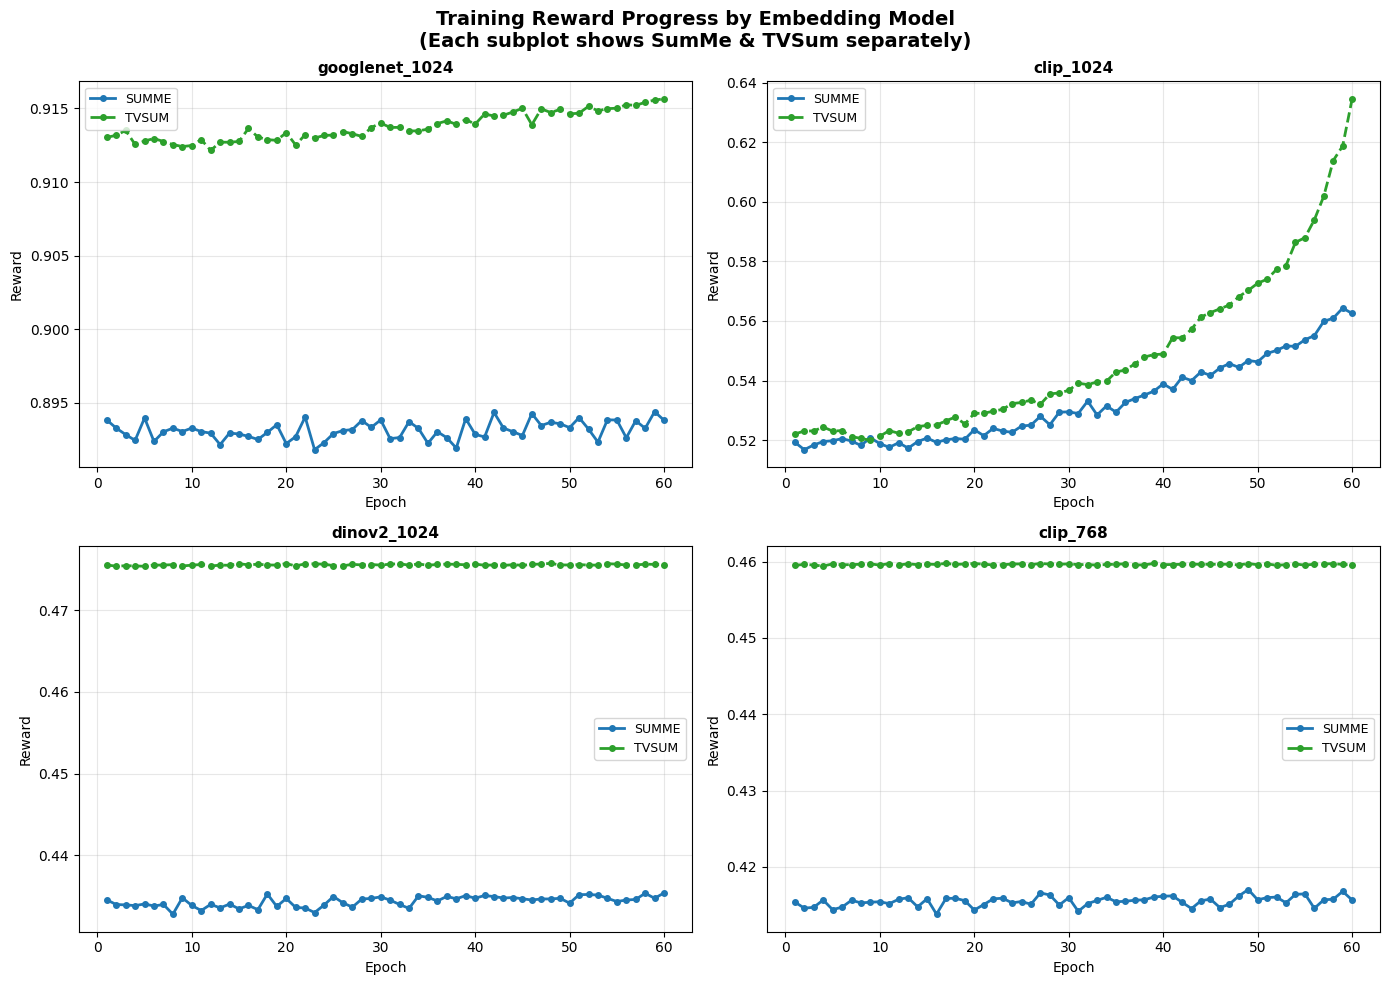

 Per-embedding reward progress plotted!


In [28]:
import matplotlib.pyplot as plt

# Plot reward progress separately for each embedding (respecting each embedding's range)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Reward Progress by Embedding Model\n(Each subplot shows SumMe & TVSum separately)', 
             fontsize=14, fontweight='bold')

embs = list(EMBEDDINGS.keys())
axes_flat = axes.flatten()

for idx, emb_name in enumerate(embs):
    ax = axes_flat[idx]
    
    for dataset_type, color, linestyle in [('summe', '#1f77b4', '-'), ('tvsum', '#2ca02c', '--')]:
        data = metrics_data[emb_name][dataset_type]
        if data['rewards']:
            label = f'{dataset_type.upper()}'
            ax.plot(data['epochs'], data['rewards'], marker='o', label=label, 
                   color=color, linestyle=linestyle, linewidth=2, markersize=4)
    
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Reward', fontsize=10)
    ax.set_title(f'{emb_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(" Per-embedding reward progress plotted!")

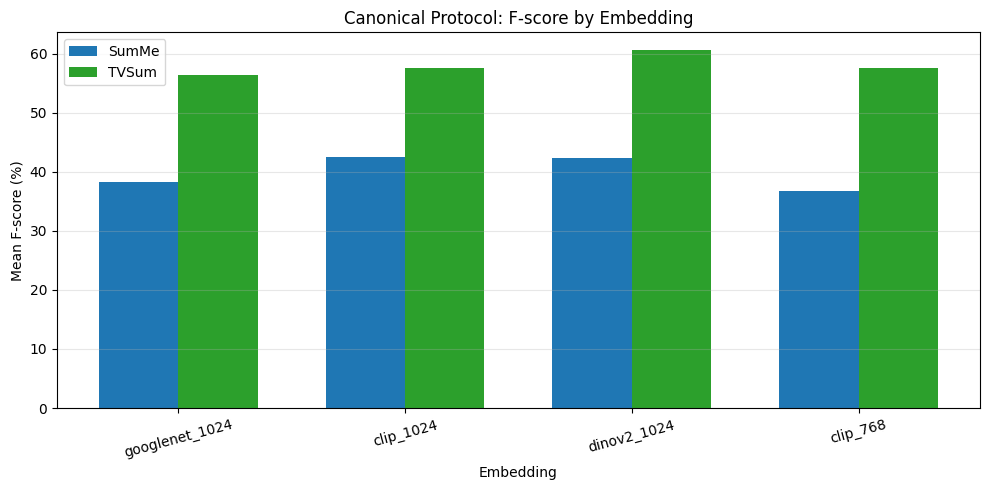

In [15]:
import matplotlib.pyplot as plt

embs = list(EMBEDDINGS.keys())
summe_scores = []
tvsum_scores = []

for emb_name in embs:
    summe_scores_emb = []
    tvsum_scores_emb = []
    
    for split_id in range(NUM_SPLITS):
        summe_log = Path(OUT_BASE) / emb_name / f'summe_split{split_id}' / 'log_test.txt'
        tvsum_log = Path(OUT_BASE) / emb_name / f'tvsum_split{split_id}' / 'log_test.txt'
        
        s = parse_fscore(summe_log)
        t = parse_fscore(tvsum_log)
        
        if s is not None:
            summe_scores_emb.append(s)
        if t is not None:
            tvsum_scores_emb.append(t)
    
    summe_scores.append(np.mean(summe_scores_emb) if summe_scores_emb else 0)
    tvsum_scores.append(np.mean(tvsum_scores_emb) if tvsum_scores_emb else 0)

x = np.arange(len(embs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, summe_scores, width, label='SumMe', color='#1f77b4')
ax.bar(x + width/2, tvsum_scores, width, label='TVSum', color='#2ca02c')

ax.set_xlabel('Embedding')
ax.set_ylabel('Mean F-score (%)')
ax.set_title('Canonical Protocol: F-score by Embedding')
ax.set_xticks(x)
ax.set_xticklabels(embs, rotation=15)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8) Save Models & Results

In [16]:
import json
import zipfile
from datetime import datetime

metadata = {
    'experiment': 'canonical_protocol',
    'date': datetime.now().isoformat(),
    'seed': SEED,
    'max_epochs': MAX_EPOCHS,
    'num_splits': NUM_SPLITS,
    'embeddings': list(EMBEDDINGS.keys()),
    'datasets': ['summe', 'tvsum'],
}

results = {}
for emb_name in EMBEDDINGS.keys():
    results[emb_name] = {
        'summe': {'scores': [], 'mean': 0, 'std': 0},
        'tvsum': {'scores': [], 'mean': 0, 'std': 0},
    }
    
    for dataset_type in ('summe', 'tvsum'):
        scores = []
        for split_id in range(NUM_SPLITS):
            log_path = Path(OUT_BASE) / emb_name / f'{dataset_type}_split{split_id}' / 'log_test.txt'
            score = parse_fscore(log_path)
            if score is not None:
                scores.append(score)
        
        results[emb_name][dataset_type]['scores'] = scores
        results[emb_name][dataset_type]['mean'] = float(np.mean(scores)) if scores else None
        results[emb_name][dataset_type]['std'] = float(np.std(scores)) if scores else None

results_json = Path(OUT_BASE) / 'canonical_results.json'
with open(results_json, 'w') as f:
    json.dump({'metadata': metadata, 'results': results}, f, indent=2)
print('Saved results to:', results_json)

zip_path = Path('/kaggle/working') / 'canonical_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUT_BASE):
        for file in files:
            fp = Path(root) / file
            arc = fp.relative_to(Path('/kaggle/working'))
            zf.write(fp, arc)

print('Zipped all outputs to:', zip_path)
print('\nExperiment complete.')

Saved results to: /kaggle/working/canonical_results/canonical_results.json
Zipped all outputs to: /kaggle/working/canonical_outputs.zip

Experiment complete.
